## import libraries and data

In [12]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
from src.extraction import load_processed, FEATURE_COLUMNS, save_model, load_model
from src.classification import build_X_y, split_data, analyze_imbalance, train_model,evaluate_models, plot_all_confusion_matrices, plot_f1_comparison, cross_validate_models, plot_cv_boxplot, tune_models, select_best_model, get_feature_importance, plot_feature_importance
from sklearn.metrics import classification_report

df_clean_clusters = load_processed("df_clean_with_target.csv")
df_clean_clusters = df_clean_clusters[FEATURE_COLUMNS + ["target"]]

df_clean_clusters

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,target
0,40.900749,95.40,0.00,95.40,0.000000,1000.0,201.802084,Clients à Faible Activité
1,3202.467416,0.00,0.00,0.00,6442.945483,7000.0,4103.032597,Clients à Risque
2,2495.148862,773.17,773.17,0.00,0.000000,7500.0,622.066742,Clients Premium
3,1666.670542,1499.00,1499.00,0.00,205.788017,7500.0,0.000000,Clients à Faible Activité
4,817.714335,16.00,16.00,0.00,0.000000,1200.0,678.334763,Clients à Faible Activité
...,...,...,...,...,...,...,...,...
8944,28.493517,291.12,0.00,291.12,0.000000,1000.0,325.594462,Clients à Faible Activité
8945,19.183215,300.00,0.00,300.00,0.000000,1000.0,275.861322,Clients à Faible Activité
8946,23.398673,144.40,0.00,144.40,0.000000,1000.0,81.270775,Clients à Faible Activité
8947,13.457564,0.00,0.00,0.00,36.558778,500.0,52.549959,Clients à Faible Activité


## Build X / y and stratified train/test split

In [13]:
X, y = build_X_y(df_clean_clusters)

X_train, X_test, y_train, y_test = split_data(X, y)

# check if the Stratification have the same proportions
display(pd.DataFrame({
    "train" : y_train.value_counts(normalize=True),
    "test"  : y_test.value_counts(normalize=True)
}))

,train,test
target,,
Clients Premium,0.399078,0.398883
Clients à Faible Activité,0.333706,0.334078
Clients à Risque,0.267216,0.267039


## Class imbalance analysis

In [14]:
table, ratio, needs_resampling = analyze_imbalance(y_train)
display(table)
print(f"Imbalance ratio (largest / smallest): {ratio}")
print("Resampling needed:", needs_resampling)

SAMPLING = "over" if needs_resampling else "none"
print("Sampling strategy used in the pipeline:", SAMPLING)

,count,pct
target,,
Clients Premium,2857,39.9
Clients à Faible Activité,2389,33.4
Clients à Risque,1913,26.7


Imbalance ratio (largest / smallest): 1.49
Resampling needed: False
Sampling strategy used in the pipeline: none


## Training the 4 pipelines

In [15]:
pipelines, train_times = train_model(X_train, y_train, sampling=SAMPLING)

display(train_times)

for name, pipeline in pipelines.items():
    print(f"{name} test accuracy = {pipeline.score(X_test, y_test):.3f}")

pipelines["svm"]

,train_time_s
model,
random_forest,0.425
svm,2.186
decision_tree,0.036
logistic_regression,0.052


random_forest test accuracy = 0.976
svm test accuracy = 0.898
decision_tree test accuracy = 0.947
logistic_regression test accuracy = 0.895


,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[object](3,)","['Clients Premium','Clients à Faible Activité','Clients à Risque']"
feature_names_in_,"ndarray[object](7,)","['BALANCE','PURCHASES','ONEOFF_PURCHASES',...,'CASH_ADVANCE', 'CREDIT_LIMIT','PAYMENTS']"
n_features_in_,int,7
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## Evaluation on the test set,

In [16]:
comparison = evaluate_models(pipelines, X_test, y_test, train_times)
display(comparison)

for name, pipeline in pipelines.items():
    print(f"===== {name} =====")
    print(classification_report(y_test, pipeline.predict(X_test), digits=3))

,accuracy,precision_macro,recall_macro,f1_macro,train_time_s
model,,,,,
random_forest,0.9760,0.9772,0.9769,0.9770,0.425
decision_tree,0.9469,0.9480,0.9488,0.9484,0.036
svm,0.8978,0.8955,0.9028,0.8984,2.186
logistic_regression,0.8950,0.8944,0.8984,0.8962,0.052


===== random_forest =====
                           precision    recall  f1-score   support

          Clients Premium      0.975     0.972     0.973       714
Clients à Faible Activité      0.965     0.973     0.969       598
         Clients à Risque      0.992     0.985     0.988       478

                 accuracy                          0.976      1790
                macro avg      0.977     0.977     0.977      1790
             weighted avg      0.976     0.976     0.976      1790

===== svm =====
                           precision    recall  f1-score   support

          Clients Premium      0.928     0.871     0.899       714
Clients à Faible Activité      0.884     0.890     0.887       598
         Clients à Risque      0.875     0.948     0.910       478

                 accuracy                          0.898      1790
                macro avg      0.896     0.903     0.898      1790
             weighted avg      0.899     0.898     0.898      1790

===== decision

In [17]:
##

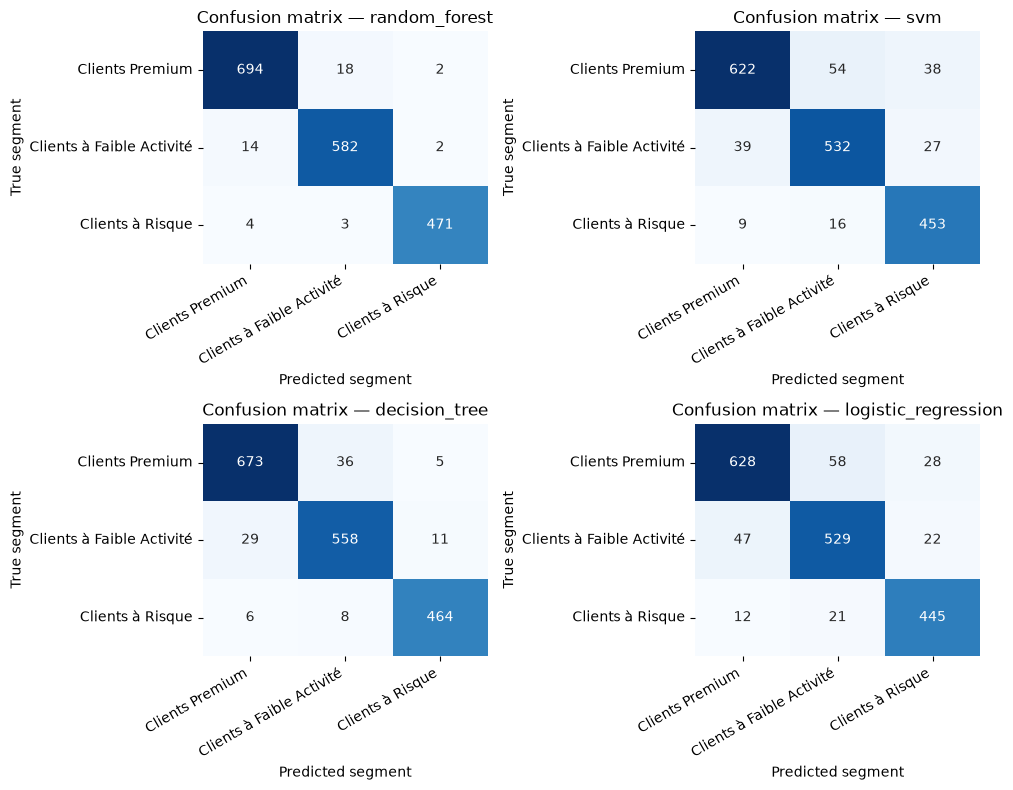

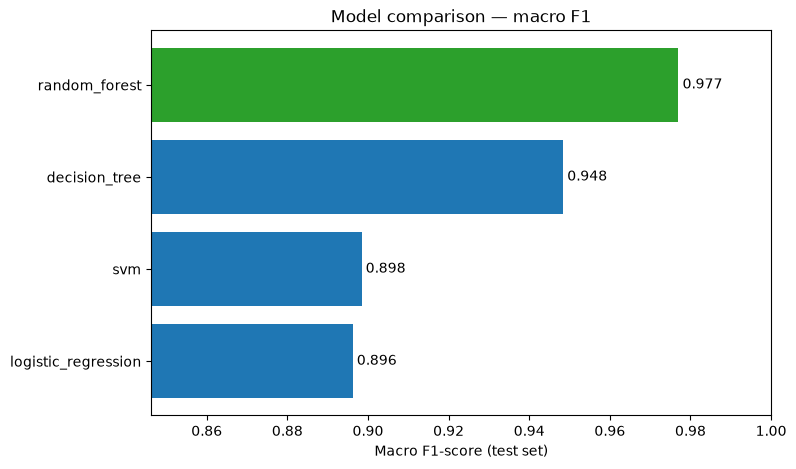

In [18]:
plot_all_confusion_matrices(pipelines, X_test, y_test)
plt.show()

plot_f1_comparison(comparison)
plt.show()

## Cross-validation (stability)

,mean,std,min,max
model,,,,
random_forest,0.9679,0.0028,0.9650,0.9709
decision_tree,0.9446,0.0037,0.9381,0.9474
svm,0.9094,0.0071,0.9008,0.9205
logistic_regression,0.9077,0.0103,0.8940,0.9212


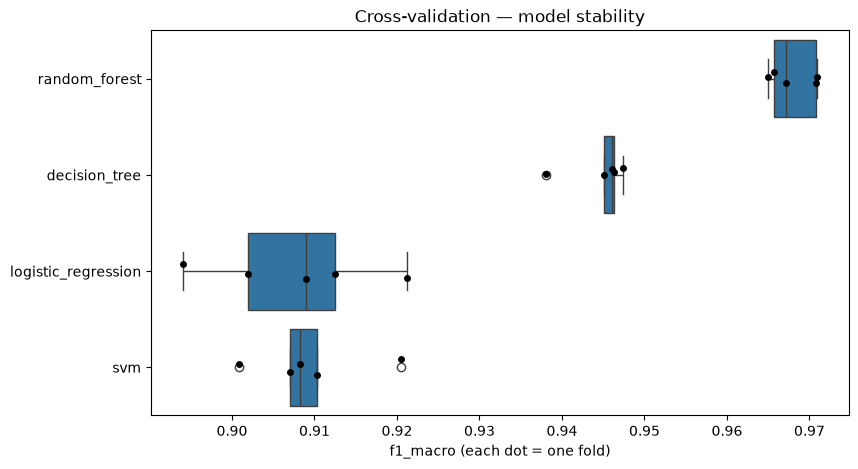

In [19]:
cv_scores = cross_validate_models(X_train, y_train, sampling=SAMPLING)

summary = (cv_scores.groupby("model")["f1_macro"]
           .agg(["mean", "std", "min", "max"])
           .sort_values("mean", ascending=False).round(4))
display(summary)

plot_cv_boxplot(cv_scores)
plt.show()

## Hyperparameter tuning

In [20]:
tuned_pipelines, tuning_summary = tune_models(X_train, y_train, sampling=SAMPLING, search="random", n_iter=20)
display(tuning_summary)

tuned_comparison = evaluate_models(
    tuned_pipelines, X_test, y_test,
    train_times=tuning_summary[["search_time_s"]],
)
display(tuned_comparison)

,best_cv_f1_macro,best_params,search_time_s
model,,,
random_forest,0.9684,"{'classifier__n_estimators': 100, 'classifier_...",22.8
decision_tree,0.9458,"{'classifier__min_samples_leaf': 1, 'classifie...",0.9
svm,0.9420,"{'classifier__estimator__gamma': 'scale', 'cla...",30.9
logistic_regression,0.9152,{'classifier__C': 100},0.4


,accuracy,precision_macro,recall_macro,f1_macro,search_time_s
model,,,,,
random_forest,0.9737,0.9750,0.9749,0.9750,22.8
decision_tree,0.9486,0.9497,0.9500,0.9498,0.9
svm,0.9346,0.9344,0.9365,0.9354,30.9
logistic_regression,0.9073,0.9076,0.9106,0.9090,0.4


## Best model, feature importance, saving,

Best model: random_forest
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])


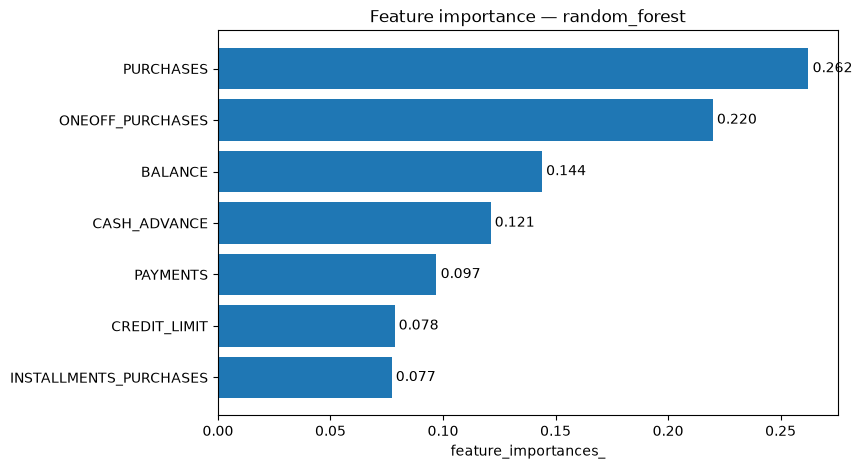

Saved to: /home/ouelaimar/Desktop/CardProfiler/models/best_pipeline.joblib


In [26]:
best_name, best_pipeline = select_best_model(tuned_comparison, tuned_pipelines)
print("Best model:", best_name)
print(best_pipeline)

importance = get_feature_importance(best_pipeline, X_test, y_test)
plot_feature_importance(importance, best_name)
plt.show()

path =  save_model(best_pipeline, "best_pipeline.joblib")
print("Saved to:", path)
